In this notebook, I will analyze how Wikipedia attention to French MPs evolves over time, covering spikes, seasonality, and the distinction between bursty and steady MPs/groups.

In [1]:
# First, let's import the necessary libraries, and read the dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

df = pd.read_csv('dataset.csv', parse_dates=['date'])
df = df.drop(columns=['qid', 'mp'])
print(df.shape)

(187245, 6)


In [2]:
# Second, let's shorten the names of groups for easier access and visuals

short_labels = {
    'groupe Rassemblement national': 'RN',
    'groupe Renaissance': 'Renaissance',
    'groupe La France insoumise': 'LFI',
    "groupe socialiste à l'Assemblée nationale": 'PS',
    'groupe Les Républicains (Assemblée nationale)': 'LR',
    'groupe écologiste': 'Ecologiste',
    'groupe démocrate (MoDem et indépendants)': 'MoDem',
    'Groupe Horizons et apparentés': 'Horizons',
    'groupe Libertés, indépendance, outre-mer et territoires': 'LIOT',
    'Groupe Union des droites pour la République': 'UDR',
    'groupe Gauche démocrate et républicaine': 'GDR',
    "non-inscrit à l'Assemblée nationale": 'Non-inscrit'
}

df['group'] = df['group'].map(short_labels)
df.head()

,name,gender,age,group,date,views
0,Lise Magnier,F,41,Horizons,2025-01-01,8
1,Lise Magnier,F,41,Horizons,2025-01-02,13
2,Lise Magnier,F,41,Horizons,2025-01-03,17
3,Lise Magnier,F,41,Horizons,2025-01-04,18
4,Lise Magnier,F,41,Horizons,2025-01-05,10


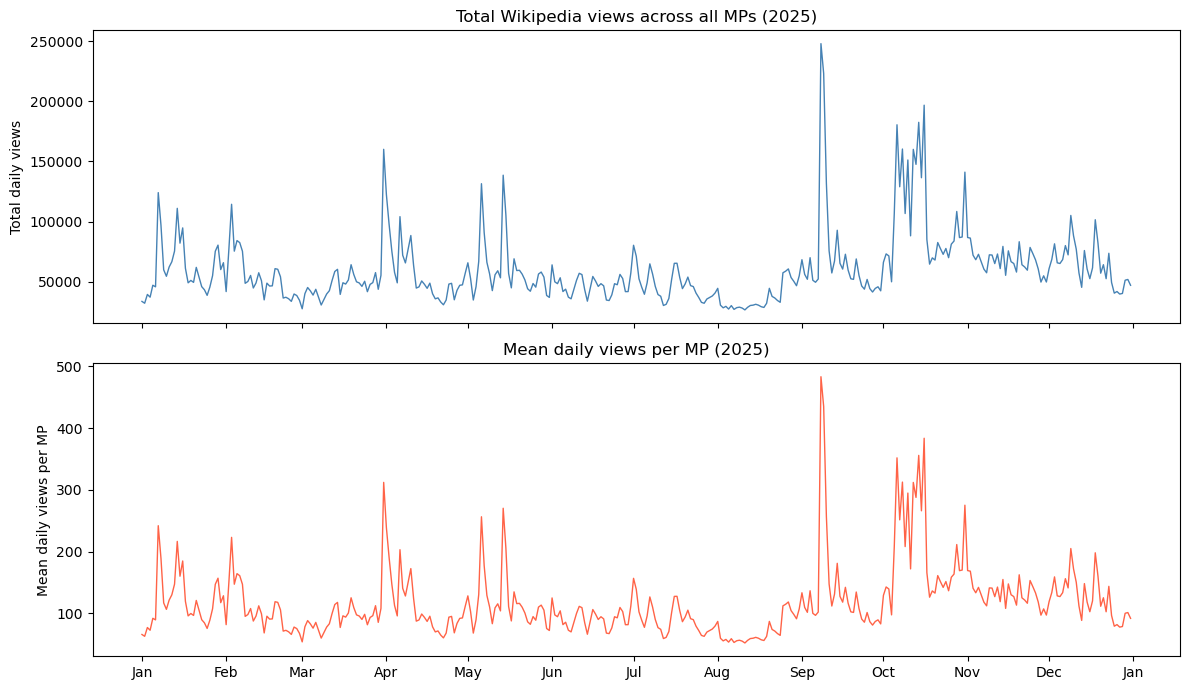

In [3]:
# Now, we will analyze the daily collective and individual attention across all MPs over time

daily_total = df.groupby('date')['views'].sum()
daily_mean = df.groupby('date')['views'].mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(daily_total.index, daily_total.values, color='steelblue', lw=1)
axes[0].set_ylabel('Total daily views')
axes[0].set_title('Total Wikipedia views across all MPs (2025)')

axes[1].plot(daily_mean.index, daily_mean.values, color='tomato', lw=1)
axes[1].set_ylabel('Mean daily views per MP')
axes[1].set_title('Mean daily views per MP (2025)')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout()
plt.show()

The two time series reveal a clear seasonal structure in public attention. Both total and mean views follow broadly the same rhythm, confirming that collective dynamics (political news, parliamentary calendar) drive attention more than individual-level noise. Attention is fluctuating between January and June, dips remarkably during summer (probably due to parliament being in recess), and then surges dramatically in September–October, the busiest political period of the year. The most prominent spike visible in the series likely corresponds to mid September to mid October (political government crisis in France).

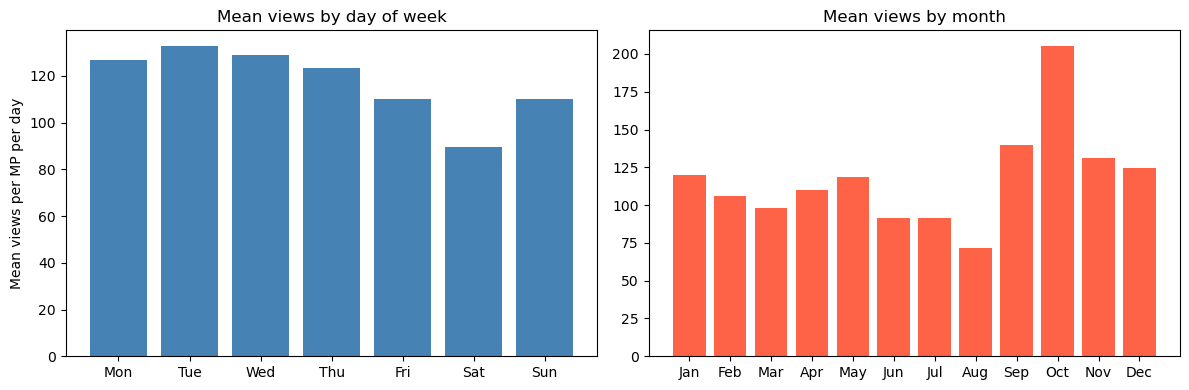

Day-of-week mean views:
  Mon: 127.0
  Tue: 132.9
  Wed: 129.0
  Thu: 123.2
  Fri: 110.0
  Sat: 89.5
  Sun: 110.2

Monthly mean views:
  Jan: 119.7
  Feb: 105.7
  Mar: 97.8
  Apr: 110.2
  May: 118.9
  Jun: 91.4
  Jul: 91.4
  Aug: 71.9
  Sep: 139.5
  Oct: 205.3
  Nov: 131.4
  Dec: 124.7


In [4]:
# Now, we're checking the situation relative to the days of the week and the months

df['weekday'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.isocalendar().week.astype(int)

dow_mean = df.groupby('weekday')['views'].mean()
month_mean = df.groupby('month')['views'].mean()

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# days plot
axes[0].bar(range(7), dow_mean.values, color='steelblue')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_names)
axes[0].set_title('Mean views by day of week')
axes[0].set_ylabel('Mean views per MP per day')

# months plot
axes[1].bar(range(1, 13), month_mean.values, color='tomato')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].set_title('Mean views by month')

plt.tight_layout()
plt.show()

print('Day-of-week mean views:')
for i, v in enumerate(dow_mean.values):
    print(f'  {day_names[i]}: {v:.1f}')

print('\nMonthly mean views:')
for i, v in zip(range(1, 13), month_mean.values):
    print(f'  {month_names[i-1]}: {v:.1f}')

Days: Attention follows a clear weekday pattern, peaking on Tuesday (132.9) and remaining high Monday through Wednesday, then declining through the week. Saturday is the clear trough, with Sunday recovering slightly. This is entirely consistent with political news cycles: parliamentary sessions, press conferences, and media coverage concentrate mid-week, driving Wikipedia lookups from an engaged, politically active audience.

Months: The monthly distribution reinforces the seasonal narrative. October stands out dramatically at 205.3 views/MP (nearly double most other months) marking it as the most attention-dense period of 2025. September (139.5) also spikes, consistent with the 'rentrée politique' but also the 2025 government crisis. August hits the floor at 71.9, confirming the recess effect. The relative strength of November and December suggests political activity remained intense late in the year, linked to government instability and the political upheaval.

In [5]:
# Here, we will be detecting spikes (unusually high attention) for MPs using the z-score method 

def count_spikes(series, threshold=3.0):
    if series.std() == 0:
        return 0
    z = (series - series.mean()) / series.std()
    return (z > threshold).sum() # z > 3

spike_stats = df.groupby('name')['views'].agg(
    spike_count=lambda x: count_spikes(x),
    total_views='sum',
    mean_views='mean',
    std_views='std'
).reset_index()

print('Top 10 MPs with most spike days:')
print(spike_stats.nlargest(10, 'spike_count')[['name', 'spike_count', 'mean_views', 'std_views']].to_string(index=False))

Top 10 MPs with most spike days:
                   name  spike_count  mean_views  std_views
    Charles Sitzenstuhl           13   38.084932  41.806211
            Éric Ciotti           13  719.131507 532.718664
        Bastien Lachaud           12  346.432877 327.772601
           Jean Terlier           12   20.846575  21.259220
Anne Stambach-Terrenoir           11   22.013699  16.153363
    Arnaud Saint-Martin           11   45.550685  29.069938
         Caroline Yadan           11  322.441096 587.560037
       Daniel Labaronne           11   22.895890  20.337539
      François Hollande           11 1538.652055 571.968340
         Lionel Vuibert           11   49.575342  41.431699


François Hollande and Éric Ciotti appear here, both high-profile figures whose baseline attention is already high, yet they still generate outlier days above their own elevated norms. Bastien Lachaud (debat de la Secu et Russie) and Caroline Yadan (loi Yadan) suggest event-driven surges.

More interesting are the low-baseline MPs with high spike counts: Charles Sitzenstuhl, Jean Terlier, Anne Stambach-Terrenoir, Daniel Labaronne, these are MPs who are normally below the radar but experienced repeated moments of sudden visibility. This pattern points to event-driven attention rather than structural prominence.

Median CV threshold: 1.31
type
Steady    170
Bursty    169
Name: count, dtype: int64


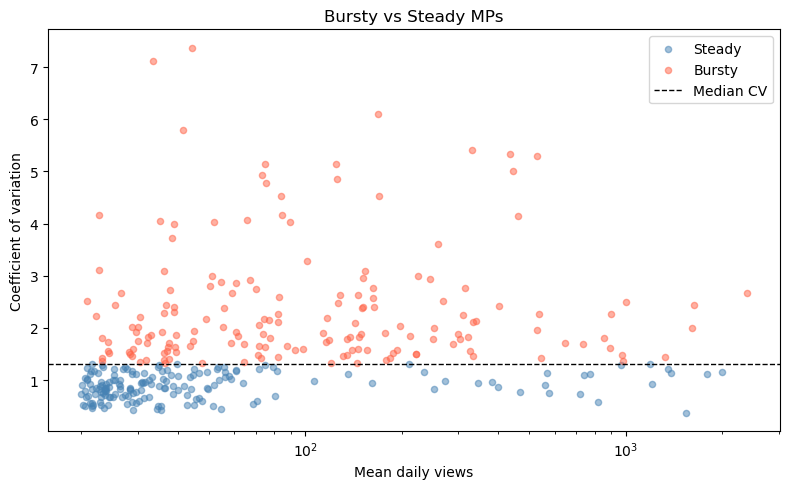


Top 10 steadiest MPs:
                  name       group  mean_views       cv
     François Hollande          PS 1538.652055 0.371733
       Thibaut Monnier          RN   35.526027 0.421418
         José Gonzalez          RN   29.079452 0.425297
Sophie Vaginay-Ricourt         UDR   34.369863 0.452151
          Joël Bruneau        LIOT   54.717808 0.454376
     Jean-Luc Warsmann        LIOT   23.509589 0.462741
    Emmanuel Fernandes         LFI   21.550685 0.467694
           David Habib        LIOT   35.356164 0.495120
      Sébastien Huyghe Renaissance   34.616438 0.497498
  Christelle d'Intorni         UDR   51.465753 0.499744

Top 10 burstiest MPs:
               name       group  mean_views       cv
   Alexandra Martin          LR   44.232877 7.374942
   Pascal Markowsky          RN   33.553425 7.123086
   Laurent Panifous        LIOT  168.232877 6.111140
     Claudia Rouaux          PS   41.687671 5.786148
Violette Spillebout Renaissance  331.128767 5.409188
        Éric Woerth 

In [6]:
# Here, we shall analyze MPs who are bursty (irregular attention spikes) vs steady (stable long-term attention) with time

mp_temporal = df.groupby(['name', 'group'])['views'].agg(
    mean_views='mean',
    std_views='std',
    total_views='sum'
).reset_index()
mp_temporal['cv'] = mp_temporal['std_views'] / mp_temporal['mean_views']

active = mp_temporal[mp_temporal['mean_views'] > 20].copy()

median_cv = active['cv'].median()
active['type'] = active['cv'].apply(lambda x: 'Bursty' if x > median_cv else 'Steady')

print(f'Median CV threshold: {median_cv:.2f}')
print(active['type'].value_counts())

fig, ax = plt.subplots(figsize=(8, 5))
for label, color in [('Steady', 'steelblue'), ('Bursty', 'tomato')]:
    sub = active[active['type'] == label]
    ax.scatter(sub['mean_views'], sub['cv'], alpha=0.5, s=20,
               label=label, color=color)
ax.axhline(median_cv, color='black', lw=1, linestyle='--', label='Median CV')
ax.set_xscale('log')
ax.set_xlabel('Mean daily views')
ax.set_ylabel('Coefficient of variation')
ax.set_title('Bursty vs Steady MPs')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 10 steadiest MPs:')
print(active.nsmallest(10, 'cv')[['name', 'group', 'mean_views', 'cv']].to_string(index=False))

print('\nTop 10 burstiest MPs:')
print(active.nlargest(10, 'cv')[['name', 'group', 'mean_views', 'cv']].to_string(index=False))

The median CV threshold of 1.31 splits the 339 active MPs almost perfectly in half (170 steady, 169 bursty), confirming that burstiness is a genuine and widespread phenomenon, not confined to a few outliers.

- Steadiest MPs are dominated by figures with durable, structural visibility: François Hollande is the clearest case. Several UDR, LIOT, and RN MPs also appear as steady, suggesting that for some parties, attention is more routine and less event-contingent.

- Burstiest MPs tell a different story. Alexandra Martin and Pascal Markowsky have very high volatility relative to their mean, they are essentially invisible most of the time, then experience extreme spikes on specific days. Laurent Panifous, Violette Spillebout, Éric Woerth, and Paul Vannier round out the bursty list, with CVs above 5. Many of these MPs experienced a specific scandal, vote, or media moment that temporarily rose them into national attention. The log-scale scatter plot underlines that burstiness is not correlated with overall fame: both low- and high-visibility MPs can be bursty.

CV by group (active MPs only):
             mean  median  count
group                           
MoDem        1.83    1.97     14
Non-inscrit  1.92    1.54     11
PS           1.76    1.48     35
LFI          1.62    1.41     59
Ecologiste   1.54    1.30     33
RN           1.59    1.29     54
LR           1.71    1.23     26
LIOT         1.94    1.19     17
Renaissance  1.64    1.19     54
GDR          1.24    1.01     11
UDR          1.72    0.99     13
Horizons     1.33    0.96     12


/tmp/ipykernel_526967/3213233988.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=order, showfliers=False)


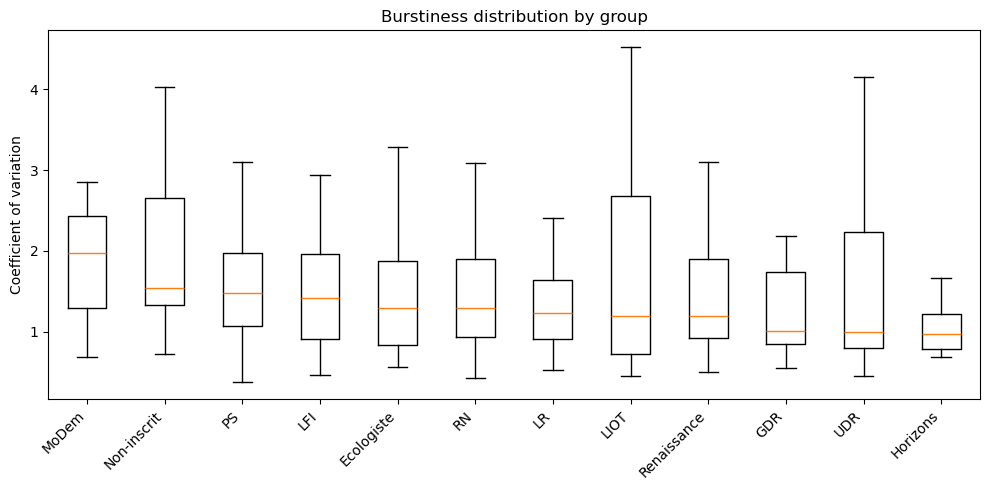

In [7]:
# Here, same as before, but for groups not individuals

group_cv = active.groupby('group')['cv'].agg(['mean', 'median', 'count']).round(2)
group_cv = group_cv.sort_values('median', ascending=False)
print('CV by group (active MPs only):')
print(group_cv.to_string())

plt.figure(figsize=(10, 5))
order = group_cv.index.tolist()
data_to_plot = [active[active['group'] == g]['cv'].values for g in order]
plt.boxplot(data_to_plot, labels=order, showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Coefficient of variation')
plt.title('Burstiness distribution by group') # active MPs, mean > 20 views/day
plt.tight_layout()
plt.show()

The group-level CV rankings expose meaningful structural differences in how attention is distributed within each political family.

MoDem and Non-inscrits are the most bursty groups. MoDem's high burstiness is somewhat surprising for a centrist coalition party, it may reflect its smaller size and the uneven weight of a few high-profile figures. Non-inscrits, by definition ungrouped and heterogeneous, naturally produce erratic attention patterns.

Horizons and UDR are the steadiest groups, both relatively small, recently formed formations whose MPs tend to stay below the national radar without dramatic individual spikes. GDR similarly shows low burstiness, consistent with a small left-wing group that generates stable but limited attention.

RN, LR, and Renaissance sit in the middle, which is notable: despite the political turbulence of 2025 affecting all three parties (RN's judicial issues, LR's fragmentation, Renaissance's governmental pressures), their median burstiness is moderate, suggesting that a large and diverse group absorbs individual spikes without uniformly lifting all members.

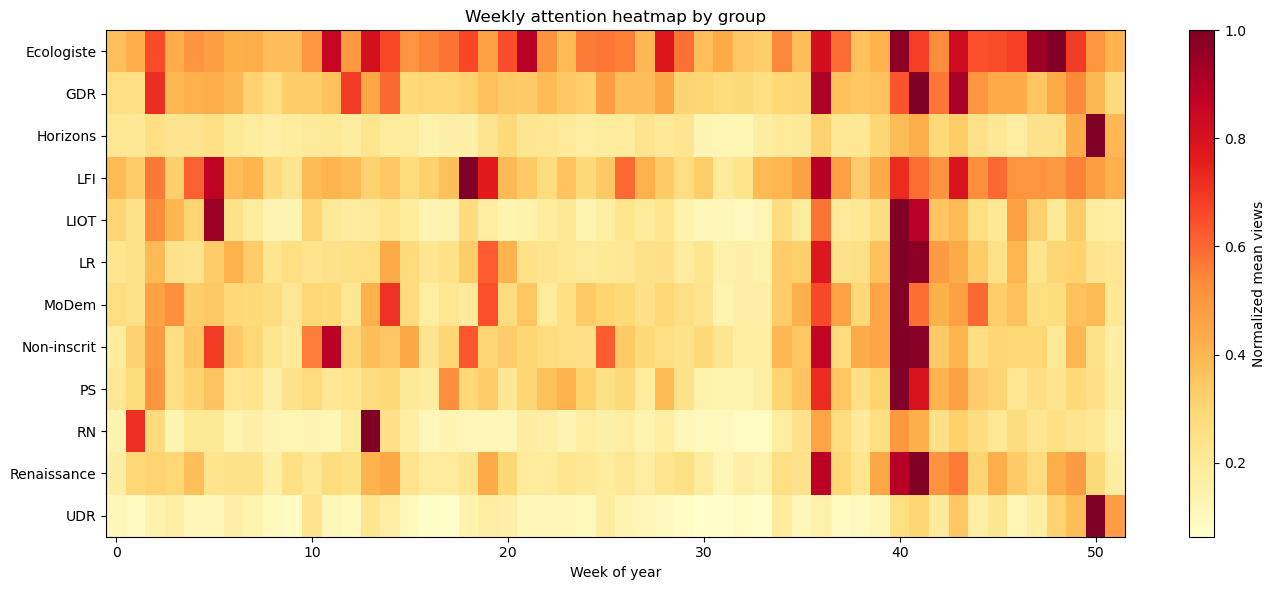

In [8]:
# Always for group analysis, here we will visualize how attention to each group evolves across weeks using a normalized heatmap

group_weekly = df.groupby(['group', 'week'])['views'].mean().unstack(level='week')
group_weekly_norm = group_weekly.div(group_weekly.max(axis=1), axis=0)

plt.figure(figsize=(14, 6))
plt.imshow(group_weekly_norm.values, aspect='auto', cmap='YlOrRd')
plt.colorbar(label='Normalized mean views')
plt.yticks(range(len(group_weekly_norm.index)), group_weekly_norm.index)
plt.xlabel('Week of year')
plt.title('Weekly attention heatmap by group')
plt.tight_layout()
plt.show()

The heatmap makes the temporal structure of group-level attention immediately legible. 

Across virtually all groups, the September–October block stands out as the peak attention period — the colour intensifies markedly around weeks 36–44 for most rows, confirming the effect of the 2025 political crisis. LFI and RN, the two largest opposition forces, show notably intense and sustained activity across this window. Renaissance, as the governing party, also shows a strong peak, reflecting heightened scrutiny during the crisis.

The summer weeks are visibly pale across all groups (parliamentary recess). 

The heatmap also reveals that some groups (GDR, Horizons, LIOT) maintain broadly low and flat attention all year, with only mild seasonal modulation, reinforcing their lower structural visibility.

In [9]:
# Here, we'll try to analyze top spike events, basically identifying the most extreme attention events for MPs

def zscore_series(x):
    if x.std() == 0:
        return pd.Series(0, index=x.index)
    return (x - x.mean()) / x.std()

df['zscore'] = df.groupby('name')['views'].transform(zscore_series)

top_spikes = df.nlargest(20, 'zscore')[['date', 'name', 'group', 'views', 'zscore']]
print('Top 20 spike events:\n')
print(top_spikes.to_string(index=False))

Top 20 spike events:

      date                  name       group  views    zscore
2025-10-16      Alexandra Martin          LR   6208 18.894806
2025-09-08 Philippe Bonnecarrère Non-inscrit   3994 18.864133
2025-05-06      Yannick Favennec        LIOT   1810 18.859302
2025-10-16      Blandine Brocard       MoDem   1500 18.796259
2025-11-05      Pascal Markowsky          RN   4502 18.696122
2025-01-21        Thierry Sother          PS   1327 18.427924
2025-03-02           Jimmy Pahun       MoDem   1080 18.395373
2025-02-07       Frédéric Falcon          RN   2073 18.180736
2025-05-21        Didier Lemaire    Horizons    849 18.032515
2025-10-28        Franck Riester Renaissance   6266 17.985803
2025-10-16       Emmanuel Blairy          RN    480 17.955589
2025-02-19    Marietta Karamanli          PS    477 17.895236
2025-10-15          Louise Morel       MoDem   1065 17.845363
2025-05-29         Manon Bouquin          RN   6475 17.684421
2025-12-09         Justine Gruet          LR   1

October concentrates the most extreme spikes. October 16 alone accounts for four entries, suggesting a single day of major political news that drew attention simultaneously to multiple MPs across different groups (LR, MoDem, RN). (height of the political crisis and budget debates)

Alexandra Martin (LR) is the single most extreme spike, an MP with a normally very low baseline who received an extraordinary surge on October 16 (since she was the only MP who voted against her own party which was highly surprising)

The cross-party and cross-month spread of this list confirms that extreme attention events are not confined to a single political moment or party, but slightly skewed towards September-October.

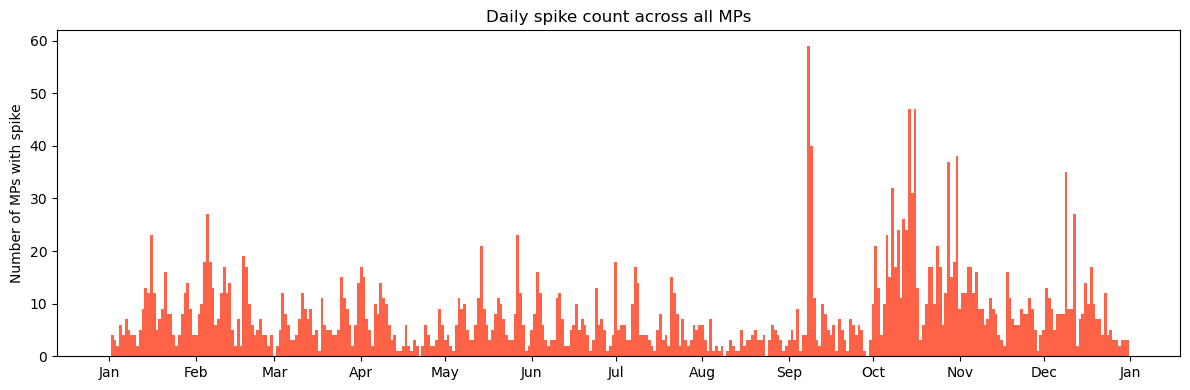

Top 10 days with most MPs spiking:

date
2025-09-08    59
2025-10-14    47
2025-10-16    47
2025-09-09    40
2025-10-31    38
2025-10-28    37
2025-12-09    35
2025-10-08    32
2025-10-15    31
2025-02-05    27


In [10]:
# Analyze top spike days over the year, by aggregating individual attention spikes to identify days with unusually high collective activity

spike_days = df[df['zscore'] > 3].groupby('date')['name'].count()
spike_days = spike_days.reindex(daily_total.index, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(spike_days.index, spike_days.values, color='tomato', width=1)
ax.set_ylabel('Number of MPs with spike')
ax.set_title('Daily spike count across all MPs')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.tight_layout()
plt.show()

print('Top 10 days with most MPs spiking:\n')
print(spike_days.nlargest(10).to_string())

The bar chart of how many MPs simultaneously spike on each day is one of the most informative views in this analysis: it captures collective political attention events, not just individual ones.

September 8 is the single most intense day of the year, with 59 MPs spiking simultaneously. This is a remarkable collective event (nearly one in ten MPs crossed their personal z > 3 threshold on the same day). 

October 14 and 16 (47 MPs) confirm the October cluster visible throughout this analysis. October 31 and 28 also appear.

February 5 (27 MPs) is the only significant winter spike. 

The overall pattern, spikes clustering in September–October with isolated winter events, closely mirrors the French parliamentary calendar.

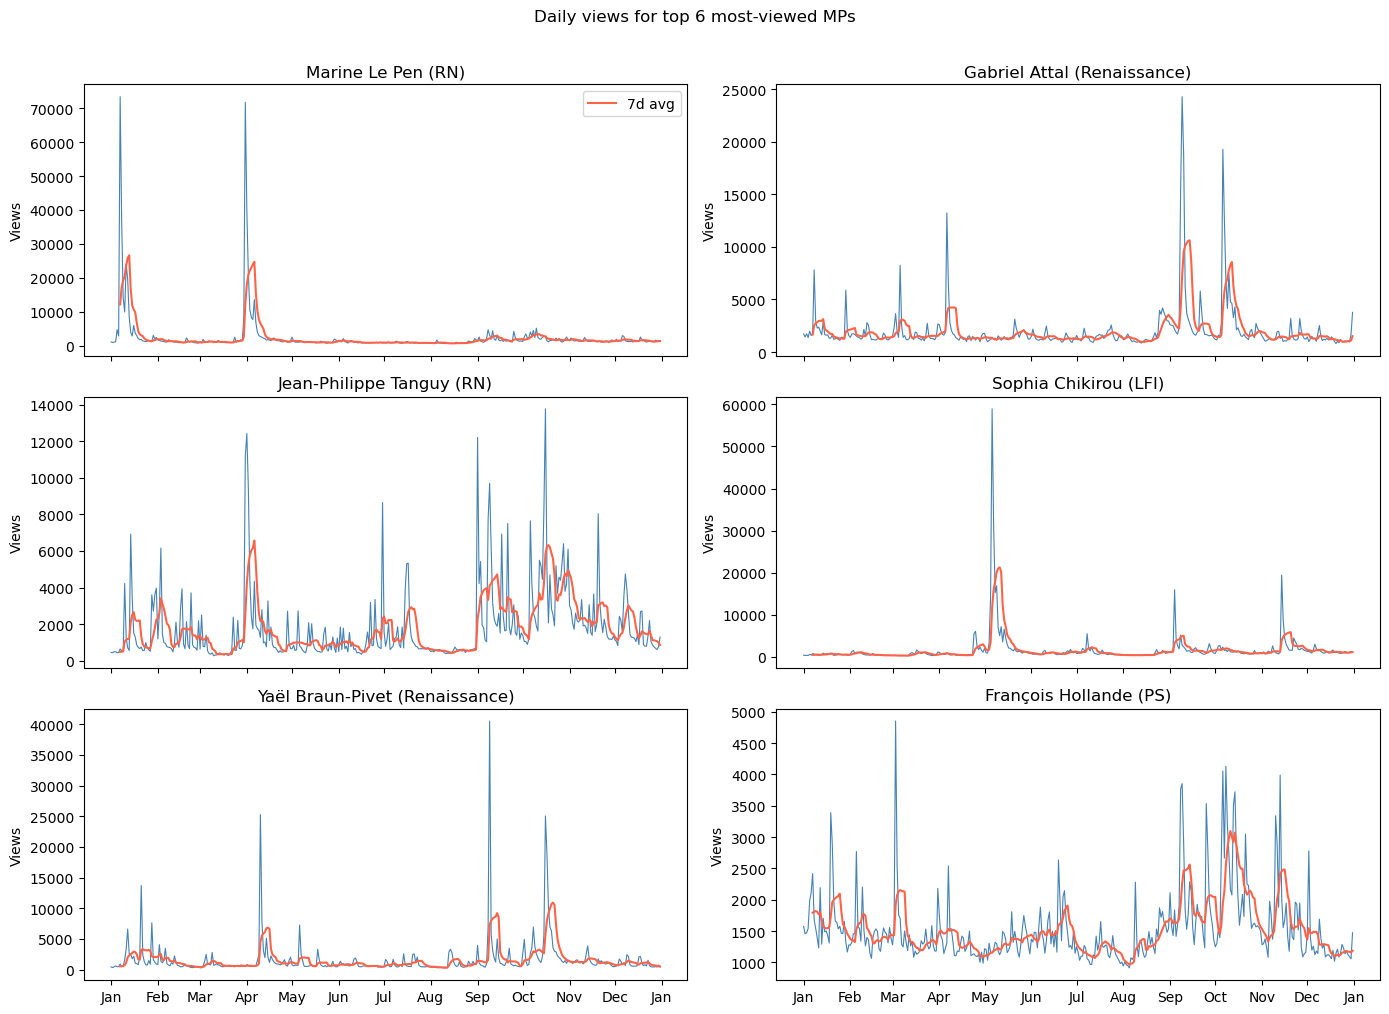

In [11]:
# Now, we will compare temporal attention patterns for the top 6 most visible MPs

top6 = df.groupby('name')['views'].sum().nlargest(6).index.tolist()

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

for i, name in enumerate(top6):
    sub = df[df['name'] == name].set_index('date')['views']
    group = df[df['name'] == name]['group'].iloc[0]
    axes[i].plot(sub.index, sub.values, lw=0.8, color='steelblue')
    axes[i].plot(sub.index, sub.rolling(7).mean(), color='tomato', lw=1.5, label='7d avg') # with 7-day rolling average
    axes[i].set_title(f'{name} ({group})')
    axes[i].set_ylabel('Views')
    if i == 0:
        axes[i].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.suptitle('Daily views for top 6 most-viewed MPs', y=1.01)
plt.tight_layout()
plt.show()

François Hollande dominates by far, as a former president and newly elected MP, his Wikipedia traffic is consistently elevated year-round, with a CV confirming it is the steadiest of all MPs. His curve is relatively flat, reflecting durable institutional fame rather than event-driven spikes.

Éric Ciotti shows a different pattern: high baseline but with sharper fluctuations, reflecting his turbulent year (his contested alliance with RN, internal LR conflicts) and the judicial proceedings around him. Paul Vannier (LFI) and Vincent Jeanbrun (LR) show bursty profiles consistent with their classification, high spikes against a lower baseline, driven by specific events.

The 7-day rolling average smooths out noise and makes the seasonal structure clearer for each MP: almost universally, the fall (September–November) shows the highest sustained attention (again, the 2025 political and budget crisis), with summer the trough. Some MPs show sharp isolated spikes followed by rapid return to baseline, a signature of event-driven attention rather than lasting public interest.

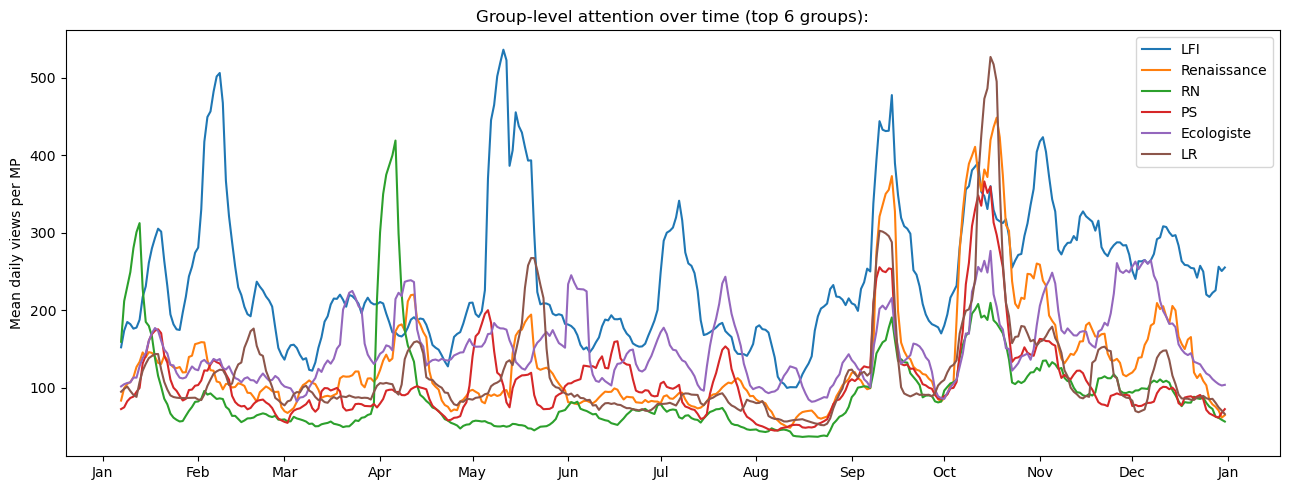

In [12]:
# Track how average attention per MP evolves over time across groups

top_groups = df.groupby('group')['views'].sum().nlargest(6).index.tolist()

fig, ax = plt.subplots(figsize=(13, 5))
colors = plt.cm.tab10.colors

for i, g in enumerate(top_groups):
    sub = df[df['group'] == g].groupby('date')['views'].mean()
    smooth = sub.rolling(7).mean() # 7-day rolling
    ax.plot(smooth.index, smooth.values, label=g, color=colors[i], lw=1.5)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_ylabel('Mean daily views per MP')
ax.set_title('Group-level attention over time (top 6 groups):')
ax.legend()
plt.tight_layout()
plt.show()

Renaissance likely maintains the highest or most sustained baseline, as the governing party. However, the September–October surge is visible across all groups, confirming that it is a systemic political event, not a party-specific one.

LFI and RN, as the two largest opposition forces and somewhat controversial, show the sharpest peaks in this period, consistent with their leading roles in no-confidence motions, budget opposition, and high-media-profile confrontations with the government. PS, strengthened by Hollande's presence and a broader left-wing coalition dynamic in 2025, also shows elevated and relatively steady attention.

The summer trough (July–August) is clearly visible across all groups simultaneously. The convergence of group curves in summer and their divergence in fall illustrates how political context modulates the visibility gap between parties: in quiet periods, all groups fade; in politically charged periods, opposition parties tend to gain disproportionate attention relative to their size.

**Global Conclusion**

Wikipedia attention to French MPs in 2025 is structured by three forces: the parliamentary calendar, political events, and individual profiles. 

The seasonal rhythm is clear, attention collapses in summer and surges in the rentrée and during the crisis, with October peaking at 205 views/MP/day. Within that rhythm, collective spike days (September 8: 59 MPs spiking simultaneously) mark real political moments, cutting across party lines. 

At the individual level, a minority of MPs enjoy durable structural visibility (Hollande being the extreme case), while most operate in event-dependent obscurity, invisible by default, briefly amplified by a single controversy or event, then forgotten. 

The data is, ultimately, a faithful mirror of French political life: quiet when parliament is quiet, loud when politics is loud.